In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import os
from hubble_utils import load_agn_data, read_quasars_from_hdf5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('style.mplstyle')

from scipy.stats import linregress
from matplotlib.lines import Line2D

colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

def plot_stone_vs_this_work(
    merged_df,
    sigma_keys,  # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    tau_keys,    # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    show=True,
    figfile='plots/appendix/stone.png'
):

    ncols = len(bands)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.05)

    axes = np.atleast_2d(axes)

    def _limits(x, y, pad=0.04):
        lo = np.nanmin([np.nanmin(x), np.nanmin(y)])
        hi = np.nanmax([np.nanmax(x), np.nanmax(y)])
        rng = max(hi - lo, 1e-6)
        return lo - pad * rng, hi + pad * rng

    def _style(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.1)

        # agn_handle = Line2D([0], [0],
        #                     marker='o', linestyle='none',
        #                     mfc='k', mec='k', markersize=6,
        #                     label='AGN')
        ax.legend(
            loc='upper left', frameon=False, fancybox=True, framealpha=1,
                  edgecolor='0.2', facecolor='white', fontsize=11)

    def _maybe_get(df, pattern, band):
        if pattern is None:
            return None
        if isinstance(pattern, tuple):
            lo = df[pattern[0].format(band=band)].to_numpy()
            up = df[pattern[1].format(band=band)].to_numpy()
            return (lo, up)
        return df[pattern.format(band=band)].to_numpy()

    def _extract_xyerr(df, keydict, band):
        x = df[keydict['x'].format(band=band)].to_numpy()
        y = df[keydict['y'].format(band=band)].to_numpy()
        xerr = _maybe_get(df, keydict.get('xerr'), band)
        yerr = _maybe_get(df, keydict.get('yerr'), band)

        m = np.isfinite(x) & np.isfinite(y)
        if isinstance(xerr, tuple):
            m &= np.isfinite(xerr[0]) & np.isfinite(xerr[1])
        elif xerr is not None:
            m &= np.isfinite(xerr)
        if isinstance(yerr, tuple):
            m &= np.isfinite(yerr[0]) & np.isfinite(yerr[1])
        elif yerr is not None:
            m &= np.isfinite(yerr)

        if m.sum() == 0:
            return None

        x, y = x[m], y[m]
        if isinstance(xerr, tuple):
            xerr = (xerr[0][m], xerr[1][m])
        elif xerr is not None:
            xerr = xerr[m]
        if isinstance(yerr, tuple):
            yerr = (yerr[0][m], yerr[1][m])
        elif yerr is not None:
            yerr = yerr[m]
        return x, y, xerr, yerr

    # ---------- Top row: σ ----------
    for ax, band in zip(axes[0], bands):
        data = _extract_xyerr(merged_df, sigma_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8,
                   label='AGN')

        xmin, xmax = _limits(x, y)
        #xmin, xmax = (-1.4, 0.9)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(sigma_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(sigma_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    # ---------- Bottom row: τ ----------
    for ax, band in zip(axes[1], bands):
        data = _extract_xyerr(merged_df, tau_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8,
                   label='AGN')

        xmin, xmax = _limits(x, y)
        #xmin, xmax = (1.4, 4.2)
        line_color = colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color, zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(tau_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(tau_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    for i in range(2):
        for j in range(1, ncols):
            axes[i, j].tick_params(labelleft=False)

    fig.savefig(figfile, dpi=600)


    if show:
        plt.show()
    plt.close(fig)


In [3]:
def load_quasar_data(prefix):
    quasar_list = read_quasars_from_hdf5(f"results/data/{prefix}.h5")
    df = pd.DataFrame(quasar_list)
    df['object_id'] = df['object_id'].astype(str)
    # for band in ['g', 'r', 'i']:
    #     df = df[df[f'log_tau_band_{band}_RF'] > 1.5]
    return df


In [6]:
df = load_quasar_data("oct26a_carma_single_lagblrband_stoneyu_spl_nofhost_bwb_taufasttruncated_nopoly1_lmc-6_N1w1000s200t14ch4")

Reading quasars from HDF5: 100%|██████████| 189/189 [00:03<00:00, 48.46it/s]


In [8]:
bwb_columns = [col for col in df.columns if 'bwb' in col]
print(bwb_columns)

['bwb_alpha_g', 'bwb_alpha_g_acf', 'bwb_alpha_g_err', 'bwb_alpha_g_ess', 'bwb_alpha_g_per_chain_variance', 'bwb_alpha_g_rhat', 'bwb_alpha_g_stuck_any', 'bwb_alpha_g_stuck_chains', 'bwb_alpha_i', 'bwb_alpha_i_acf', 'bwb_alpha_i_err', 'bwb_alpha_i_ess', 'bwb_alpha_i_per_chain_variance', 'bwb_alpha_i_rhat', 'bwb_alpha_i_stuck_any', 'bwb_alpha_i_stuck_chains', 'bwb_alpha_r', 'bwb_alpha_r_acf', 'bwb_alpha_r_err', 'bwb_alpha_r_ess', 'bwb_alpha_r_per_chain_variance', 'bwb_alpha_r_rhat', 'bwb_alpha_r_stuck_any', 'bwb_alpha_r_stuck_chains', 'bwb_alpha_u', 'bwb_alpha_u_err', 'bwb_alpha_z', 'bwb_alpha_z_acf', 'bwb_alpha_z_err', 'bwb_alpha_z_ess', 'bwb_alpha_z_per_chain_variance', 'bwb_alpha_z_rhat', 'bwb_alpha_z_stuck_any', 'bwb_alpha_z_stuck_chains', 'bwb_alpha_u_acf', 'bwb_alpha_u_ess', 'bwb_alpha_u_per_chain_variance', 'bwb_alpha_u_rhat', 'bwb_alpha_u_stuck_any', 'bwb_alpha_u_stuck_chains']


Reading quasars from HDF5: 100%|██████████| 189/189 [00:02<00:00, 65.83it/s]


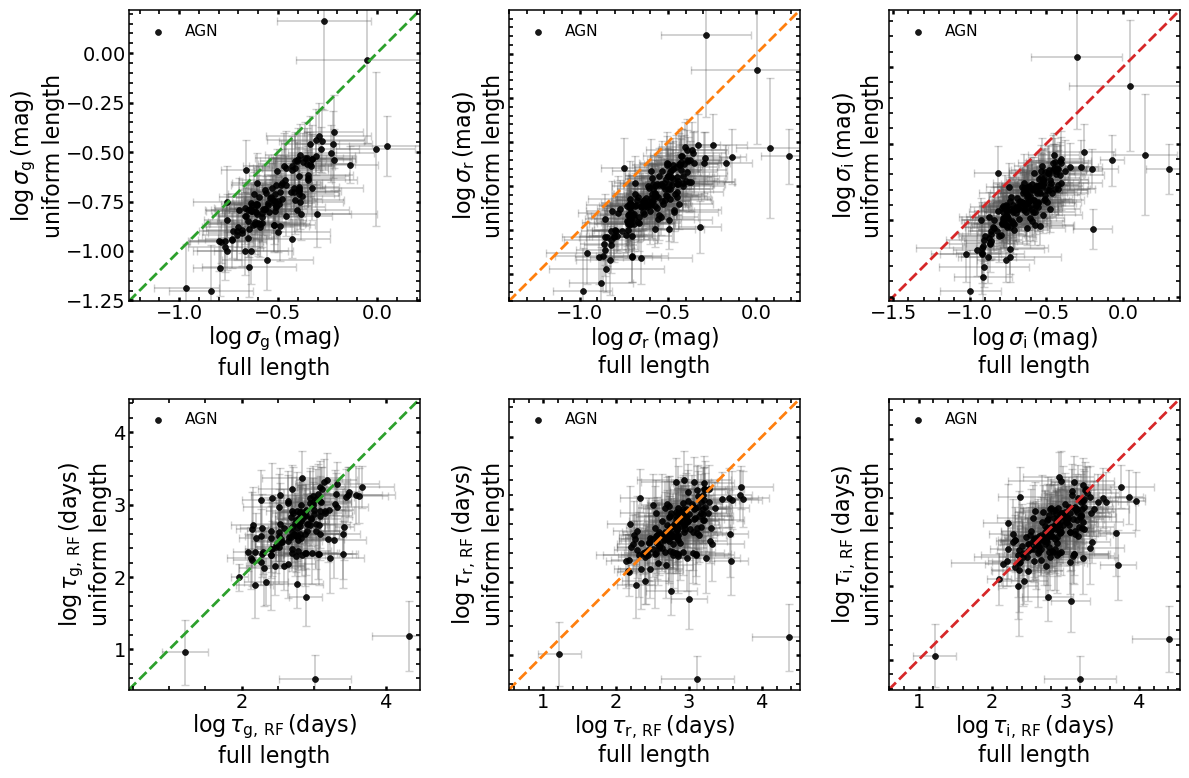

Reading quasars from HDF5: 100%|██████████| 189/189 [00:03<00:00, 57.24it/s]


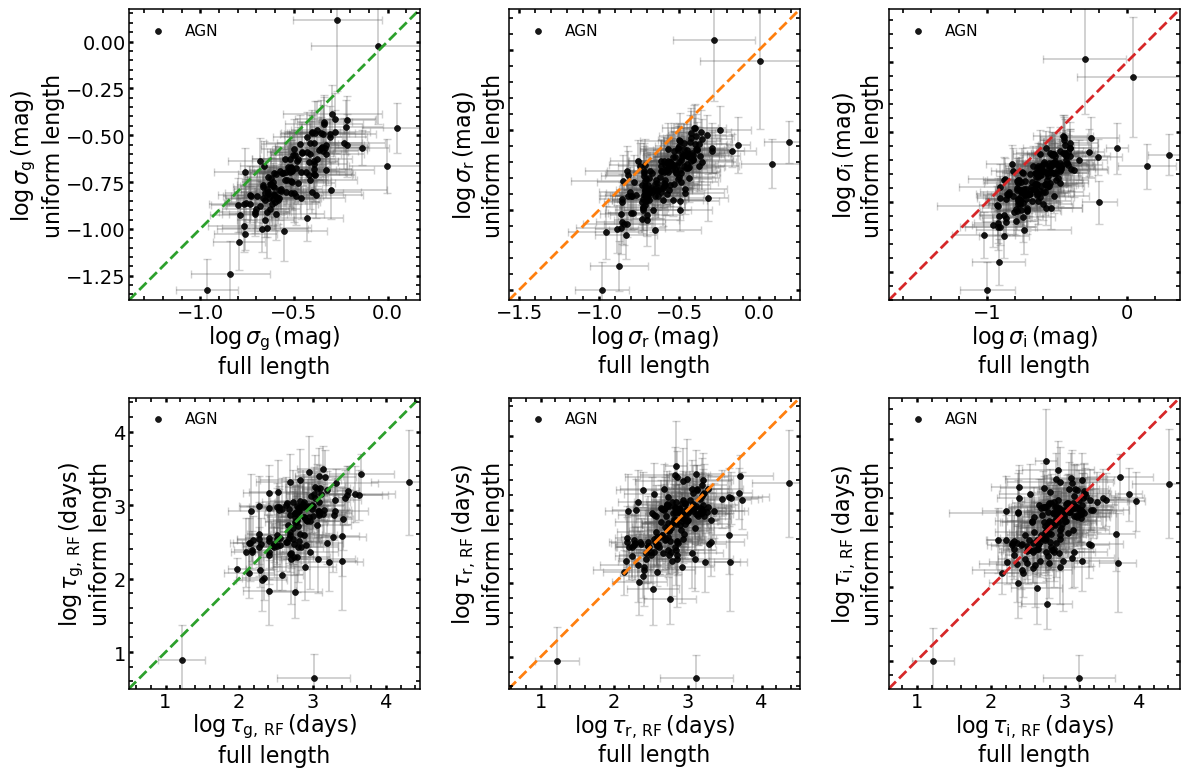

In [10]:
# Same length 
df_1 = load_quasar_data("oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4")

for prefix in [
    #'oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_lmc-6_N1w1000s200t14ch4',
    #'oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_nopoly1_lmc-6_N1w1000s200t14ch4'
    'dec5a_single_stoneyu_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_lmc-6_N1w1000s200t14ch4',
    'dec5a_single_stoneyu_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_stoneyu_spl_nofhost_bwb_rflengthcut2400_nopoly1_lmc-6_N1w1000s200t14ch4',
    
    ]:
    df_2 = load_quasar_data(prefix)

    merged_agn = pd.merge(df_1, df_2, on='object_id', how='inner', suffixes=('_1', '_2'))

    # New fit compare
    sigma_keys = {
        'x': 'log_sigma_band_{band}_1',
        'y': 'log_sigma_band_{band}_2',
        'xerr': 'log_sigma_band_{band}_err_1',
        'yerr': 'log_sigma_band_{band}_err_2',
        'xlabel': r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$' + '\nfull length',
        'ylabel': r'$\log\!\,\sigma_{{\mathrm{{{band}}}}}\,(\mathrm{{mag}})$' + '\nuniform length',
    }

    tau_keys = {
        'x': 'log_tau_band_{band}_RF_1',
        'y': 'log_tau_band_{band}_RF_2',
        'xerr': 'log_tau_band_{band}_RF_err_1',
        'yerr': 'log_tau_band_{band}_RF_err_2',
        'xlabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\nfull length',
        'ylabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\nuniform length',
    }


    plot_stone_vs_this_work(merged_agn, sigma_keys, tau_keys, bands=('g','r','i'), figfile=f"plots/appendix/stone_tests/stonelcs_samelength_{prefix}.pdf")

Reading quasars from HDF5:   0%|          | 0/188 [00:00<?, ?it/s]

Reading quasars from HDF5: 100%|██████████| 188/188 [00:04<00:00, 46.64it/s]


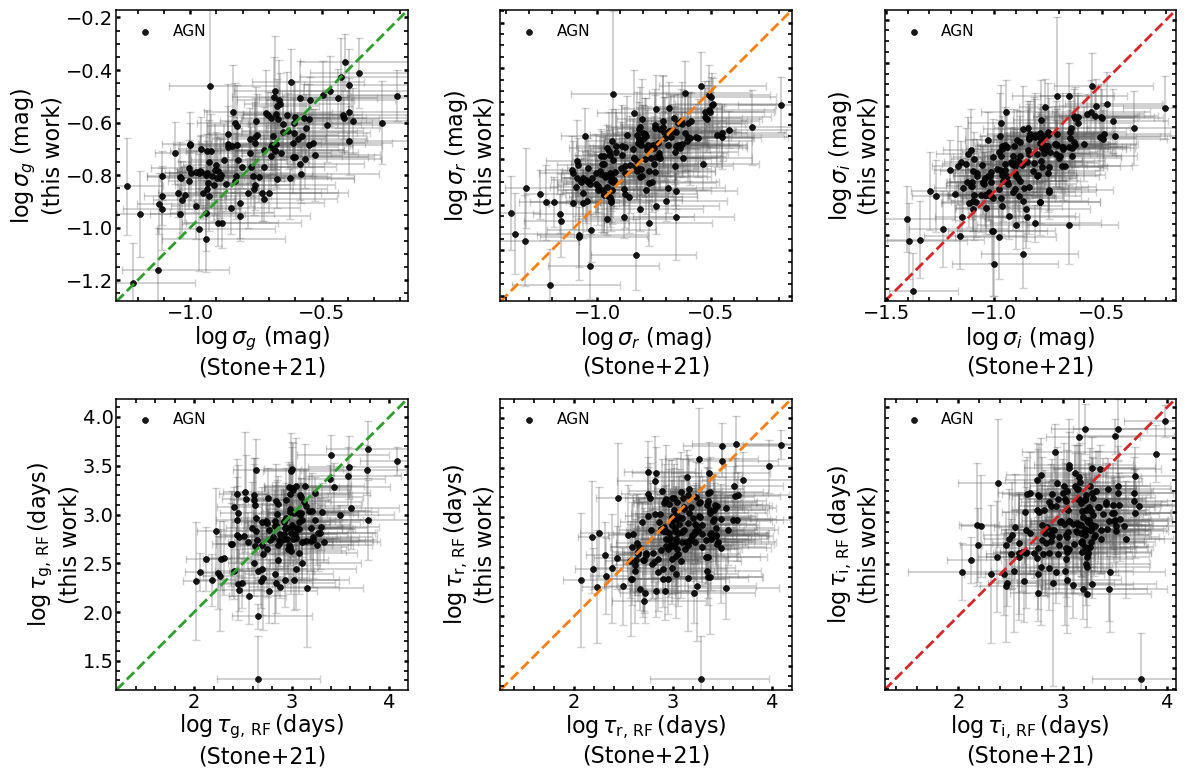

Reading quasars from HDF5: 100%|██████████| 189/189 [00:02<00:00, 63.62it/s]


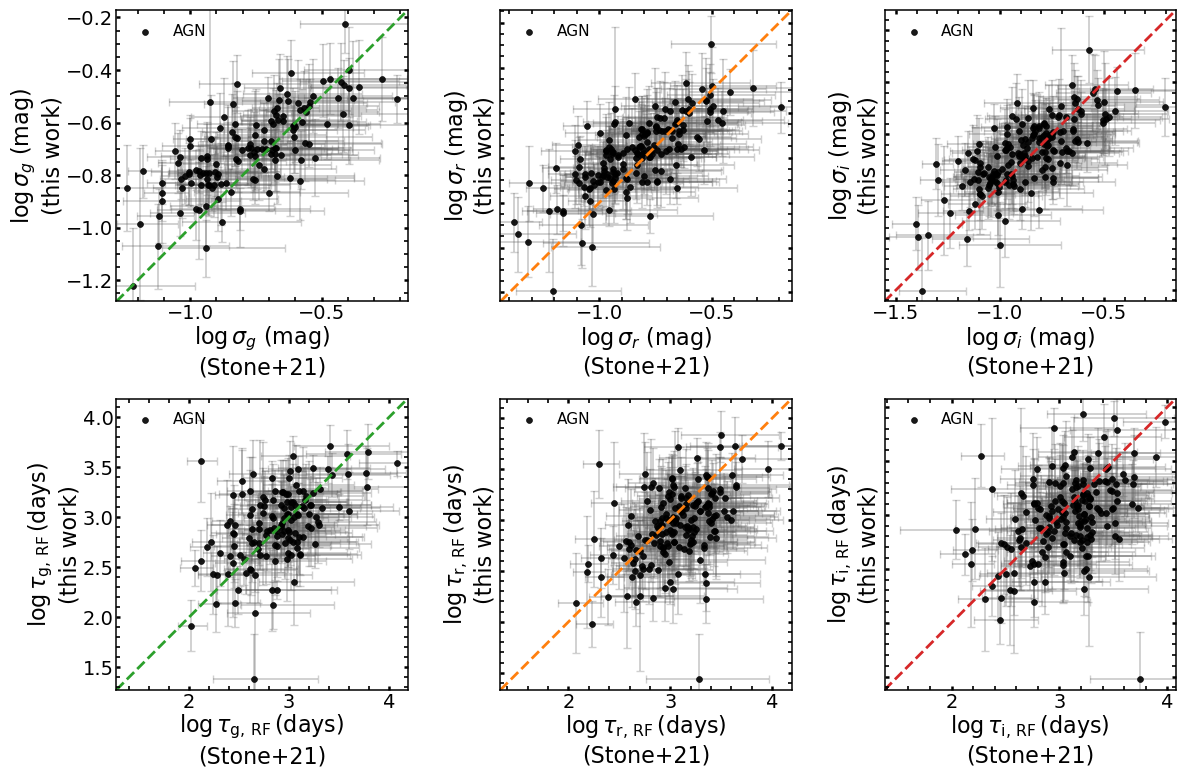

In [15]:
# Stone vs Stone LCs fitted no lag blr
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log\!\,\sigma_{{{band}}}$ (mag)' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\sigma_{{{band}}}$ (mag)' + '\n(this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\tau_{{\mathrm{{{band}}},\,\mathrm{{RF}}}}\,(\mathrm{{days}})$' + '\n(this work)',
}

for prefix in [
    #"oct28b_single_carma_lagblrband_stoneyu_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4",
    #"oct26a_carma_single_lagblrband_stoneyu_spl_nofhost_bwb_taufasttruncated_nopoly1_lmc-6_N1w1000s200t14ch4",
    "dec5a_single_stoneyu_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_stoneyu_spl_nofhost_bwb_lmc-6_N1w1000s200t14ch4",
    "dec5a_single_stoneyu_chisq_carma_mixscalar_nozband_highertaufastlim_removemix_fixband_lagblrband_stoneyu_spl_nofhost_bwb_nopoly_lmc-6_N1w1000s200t14ch4"
    ]:
    #"oct22a_single_stoneyu_lagblrband_stoneyu_spl_nofhost_lmc-6_N1w2000s400t14ch4",
    #"oct23a_single_stoneyu_lagblrband_stoneyu_spl_nofhost_nopoly1_lmc-6_N1w2000s400t14ch4",

    # Load stone data
    stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
    stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

    df_agn = load_quasar_data(prefix)

    # Load standard data
    # for b in ['g', 'r', 'i']:
    #     #df_agn[f'log_sigma_band_{b}_mixed'] = df_agn[f'log_sigma_band_{b}'] * df_agn[f'bwb_alpha']
    #     df_agn[f'log_sigma_band_{b}'] = df_agn[f'log_sigma_band_{b}']-np.log10(np.sqrt(2))

    os.makedirs("plots/appendix/stone_tests", exist_ok=True)
    merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
    plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile=f"plots/appendix/stone_tests/stonelcs_stonetest_{prefix}_mixed.pdf")

Reading quasars from HDF5: 100%|██████████| 168/168 [00:01<00:00, 91.17it/s]


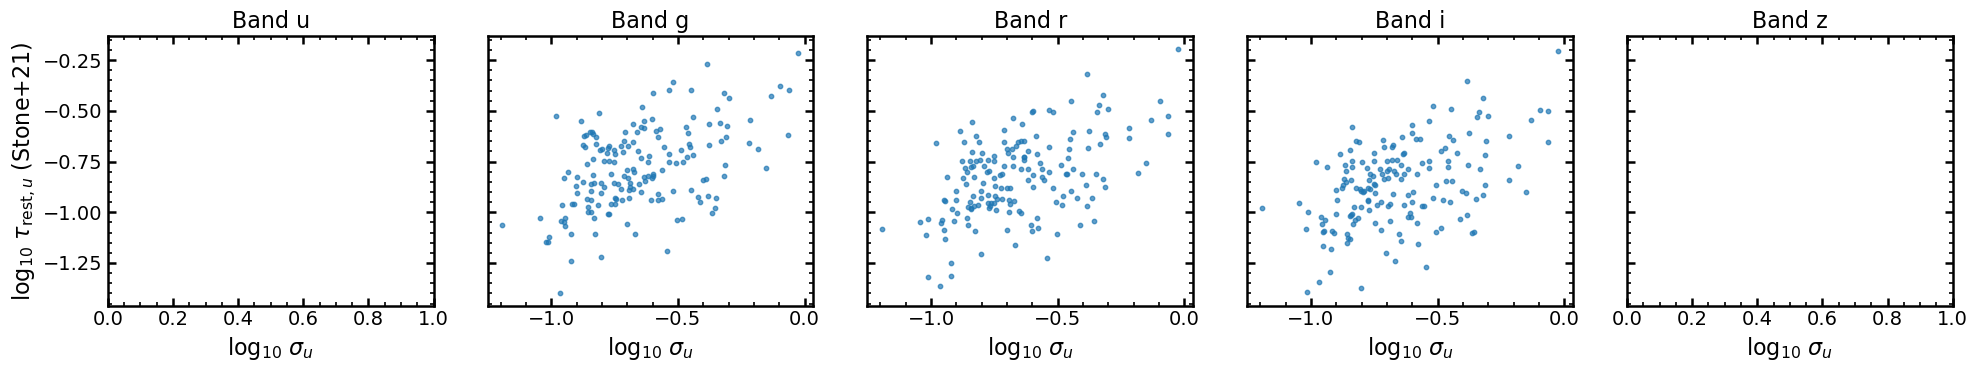

In [23]:
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

prefix = "oct11a_lagblrband_stonelcs_spl_nofhost_nopoly1_nobwb_lmc-6_N1w1000s200t14ch4"

# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

quasar_list = read_quasars_from_hdf5(f"results/data/{prefix}.h5")
df_agn = pd.DataFrame(quasar_list)
df_agn['object_id'] = df_agn['object_id'].astype(str)

# Load standard data
for b in ['g', 'r', 'i']:
    df_agn[f'log_sigma_band_{b}'] = df_agn[f'log_sigma_band_{b}']#-np.log10(np.sqrt(2))

os.makedirs("plots/appendix/stone_tests", exist_ok=True)
merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
bands = ['u', 'g', 'r', 'i', 'z']
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for idx, band in enumerate(bands):
    ax = axes[idx]
    x = df_agn.get('log_sigma_band_i')
    y = stone_df.get(f'stone_log_SIGMA_{band}')
    if x is not None and y is not None:
        # Align by object_id
        merged = pd.merge(df_agn[['object_id', 'log_sigma_band_r']], 
                          stone_df[['object_id', f'stone_log_SIGMA_{band}']], 
                          on='object_id', how='inner')
        ax.scatter(merged['log_sigma_band_r'], merged[f'stone_log_SIGMA_{band}'], s=10, alpha=0.7)
    ax.set_title(f'Band {band}')
    ax.set_xlabel(r'$\log_{10}\,\sigma_u$')
    if idx == 0:
        ax.set_ylabel(rf'$\log_{{10}}\,\tau_{{\mathrm{{rest}},{band}}}$ (Stone+21)')
plt.tight_layout()
plt.show()


In [4]:
# Stone Comparison wo/ poly1

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load stone data
stone_df = pd.read_csv('data/aug8_stone_merged.csv')
stone_df['object_id'] = stone_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/sep29g_preview_stonelcs_spl_lmc-4_N20w4000s1000t8co4ch4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wopoly1.pdf")


FileNotFoundError: [Errno 2] No such file or directory: 'data/aug8_stone_merged.csv'

Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 268.09it/s]


Number of quasars loaded: 180


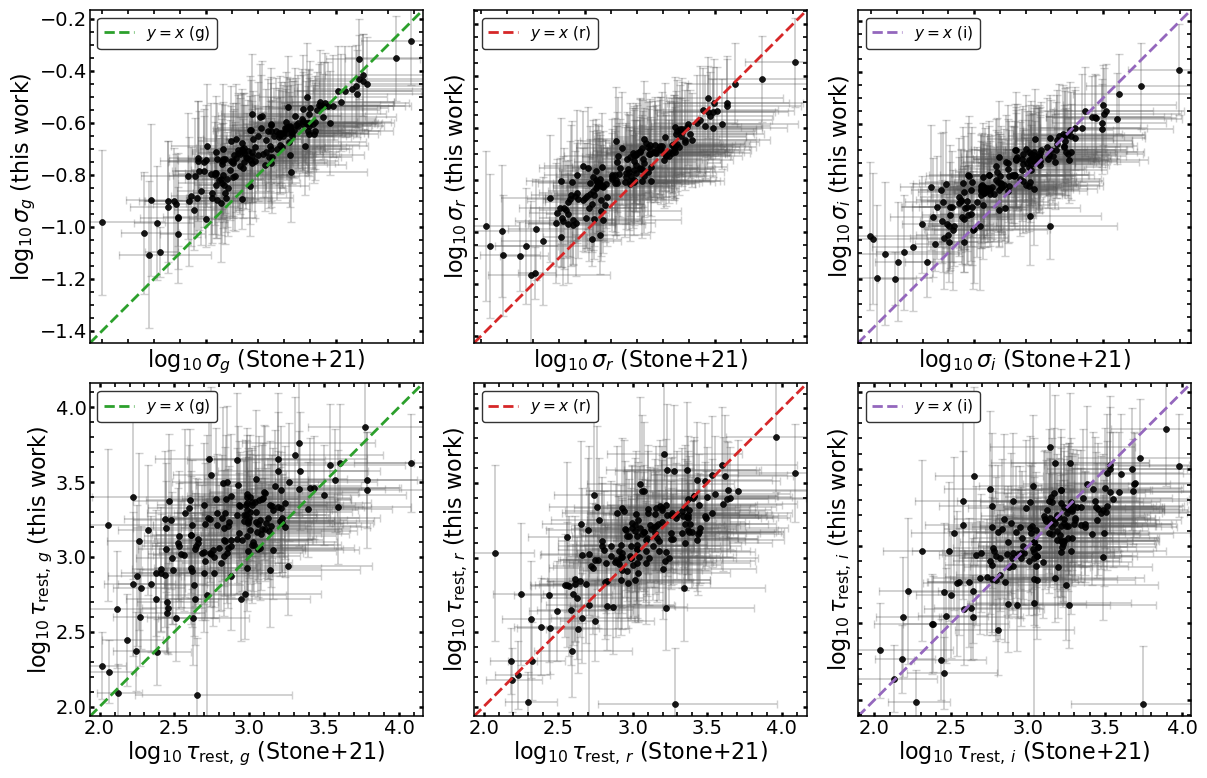

In [ ]:
# Stone vs Stone LCs fitted no lag blr
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

# Load standard data
agn_df = load_agn_data("results/data/sep3_chisq_stonelc_nobwb_nopoly1_nolagblr_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)
agn_df = agn_df.dropna(axis=0, subset=agn_df.select_dtypes(include=[np.number]).columns)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_vs_stonelc_wopoly1_nolagblr.pdf")

# Print object_id of objects close to the y=x line for g, r, i bands
bands = ['g', 'r', 'i']
tol = 0.05  # tolerance in log space

In [ ]:
band = 'r'
x = merged_agn_stone[f'stone_log_TAU_REST_{band}']
y = merged_agn_stone[f'log_tau_band_{band}_RF']
close = np.abs(x - y) < tol
print(f"Band {band}:")
merged_agn_stone.loc[close, ['object_id', 'stone_log_TAU_REST_r', 'log_tau_band_r_RF']].head(32)

print(merged_agn_stone.loc[close, 'object_id'].head(32).to_list())

Band r:
['1389354', '1388636', '1387156', '1390435', '1390004', '1387687', '1387472', '1389486', '1389477', '1389026', '1388234', '1389767', '1388067', '1387164', '1387743', '1391150', '1387579', '1389488', '1389884', '1388577', '1387551', '1388817', '1387544', '1391199', '1390491', '1386655', '1387151', '1389198', '1388304', '1388819', '1388389', '1389088']


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 244.56it/s]


Number of quasars loaded: 180
[WARNING] alpha_lambda not in df, populating from CSV
Length of colin_df: 4000
Number with apparent_mag_2500 > 0: 3966
Length of merged DataFrame: 180
object_id not in merged: ['1388108', '1390331', '1387544', '1391217', '1390021', '1388070', '1388467', '1387618', '1390597', '1387321', '1389786', '1390026', '1387226', '1387164', '1387743', '1388389', '1389038', '1387528', '1389887', '1388577', '1389560', '1390319', '1390576', '1390992', '1388483', '1387174', '1387205', '1386720', '1387518', '1388573', '1391675', '1387938', '1390151', '1388366', '1389799', '1389026', '1388943', '1387264', '1388067', '1387099', '1389486', '1386875', '1391583', '1387876', '1388730', '1386822', '1388442', '1387472', '1389289', '1390559', '1390847', '1389832', '1390243', '1387714', '1387687', '1387044', '1389767', '1387579', '1388513', '1388643', '1387119', '1388819', '1387641', '1390490', '1389630', '1390080', '1387685', '1390677', '1387725', '1390858', '1388340', '1388047', '

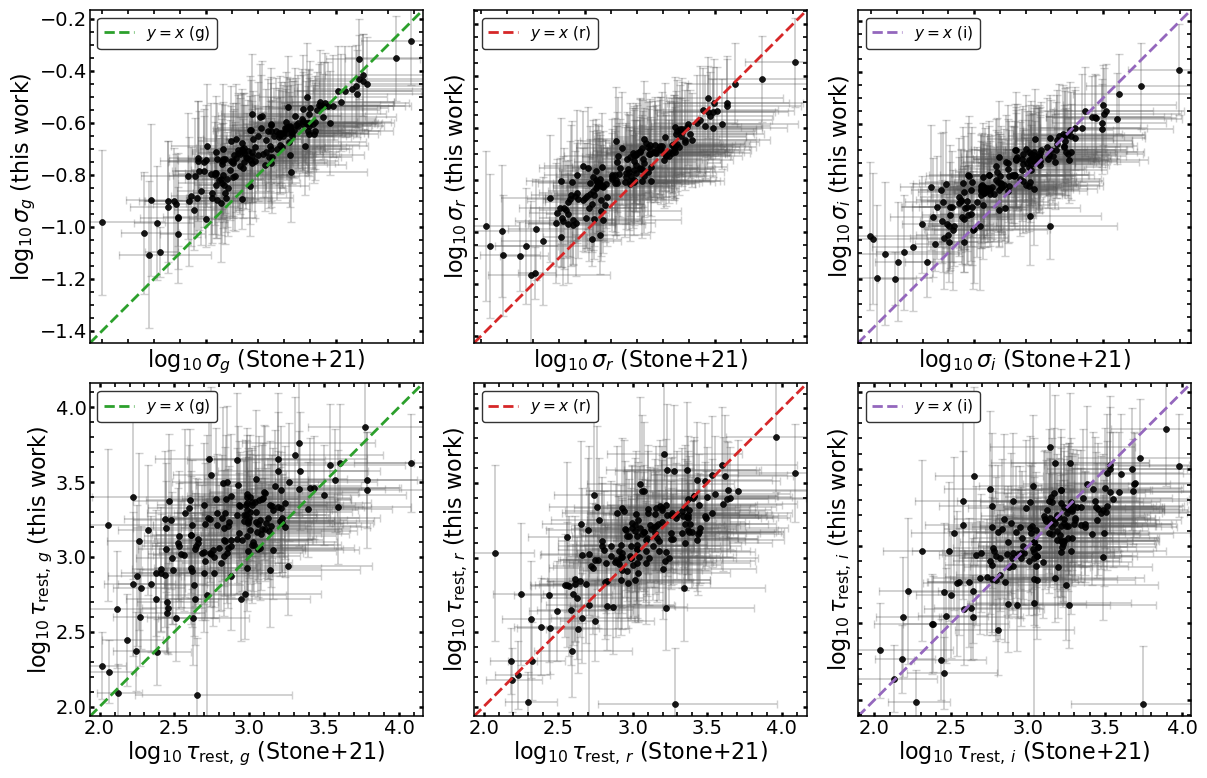

In [ ]:
# Stone vs Stone LCs fitted
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

# Load standard data
agn_df = load_agn_data("results/data/sep2_chisq_stonelc_nobwb_nopoly1_N20w4000s1000t8c4_spectralfit.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)
agn_df = agn_df.dropna(axis=0, subset=agn_df.select_dtypes(include=[np.number]).columns)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_vs_stonelc_wopoly1.pdf")


In [ ]:
# Stone Comparison w/ poly1
sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/aug8_stone_merged.csv')
stone_df['object_id'] = stone_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/aug19_stone_nobwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wpoly1.pdf")


NameError: name 'pd' is not defined

In [ ]:
# Same Length Comparison
sigma_keys = {
    'x': 'log_sigma_band_{band}_agn',
    'y': 'log_sigma_band_{band}_samelength',
    'xerr': 'log_sigma_band_{band}_err_agn',
    'yerr': 'log_sigma_band_{band}_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_tau_band_{band}_RF_agn',
    'y': 'log_tau_band_{band}_RF_samelength',
    'xerr': 'log_tau_band_{band}_RF_err_agn',
    'yerr': 'log_tau_band_{band}_RF_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load AGN same length data
agn_samelength_df = load_agn_data("results/data/aug25_stone_nobwb_poly1_samelength2400_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_samelength_df['object_id'] = agn_samelength_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/aug19_stone_nobwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_samelength = pd.merge(agn_samelength_df, agn_df, on='object_id', how='inner', suffixes=('_samelength', '_agn'))

plot_stone_vs_this_work(merged_agn_samelength, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_samelength_2400days.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 313.49it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


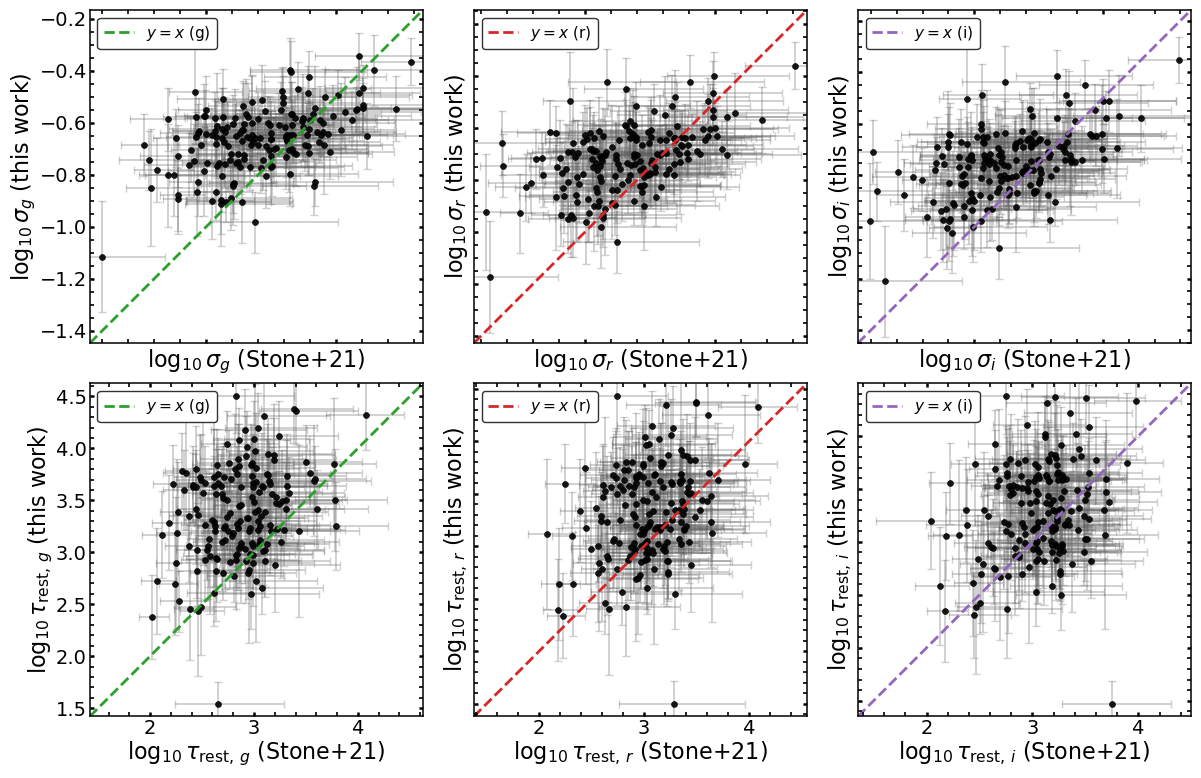

In [ ]:
# Stone Comparison wo/ poly1 w/ bwb

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load standard data
agn_df = load_agn_data("results/data/aug20_stone_bwb_nopoly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_wopoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 310.74it/s]
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
/tmp/ipykernel_959447/4034639757.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


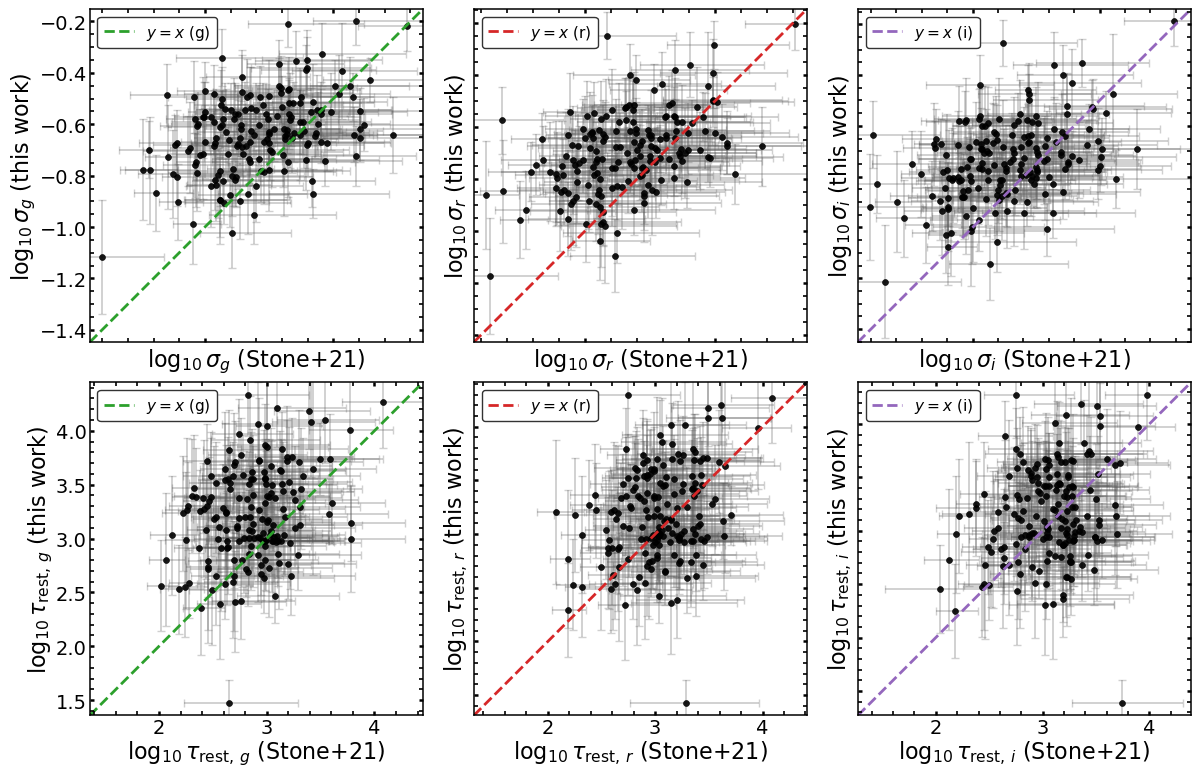

In [ ]:
# Stone Comparison bwb, no poly1

def drw_equiv(amp_cont, tau_drw, bwb_alpha, bwb_beta):
    A = amp_cont
    q2 = (bwb_alpha * A**2)**2  # q_b^2

    sigma2_eq = A**2 + 2.0 * q2
    tau_eq = tau_drw * (A**2 + (2.0/bwb_beta)*q2) / (A**2 + 2.0*q2)
    return np.sqrt(sigma2_eq), tau_eq

agn_df = load_agn_data("results/data/aug20_stone_bwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)


for band in ('g','r','i'):
    sigma = 10**agn_df[f'log_sigma_band_{band}']
    tau = 10**agn_df[f'log_tau_band_{band}_RF']
    sigma_eq, tau_eq = drw_equiv(sigma, tau, bwb_alpha=agn_df['bwb_alpha'], bwb_beta=agn_df['bwb_beta'])
    agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
    agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}_eq',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF_eq',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_poly1.pdf")


Reading quasars from HDF5: 100%|██████████| 13160/13160 [00:48<00:00, 273.66it/s]


Number of quasars loaded: 13160
Number of quasars with 0 < z <= 1.0: 3204
Number of quasars with z > 3: 405
Highest redshift quasar: 4.455935435869128
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mags_mean_g', 'mags_mean_u', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err']
Skipping data cuts as apply_cut is False.


Reading quasars from HDF5: 100%|██████████| 3920/3920 [00:16<00:00, 243.79it/s]


Number of quasars loaded: 3920
Number of quasars with 0 < z <= 1.0: 965
Number of quasars with z > 3: 112
Highest redshift quasar: 4.32306007971774
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Skipping data cuts as apply_cut is False.


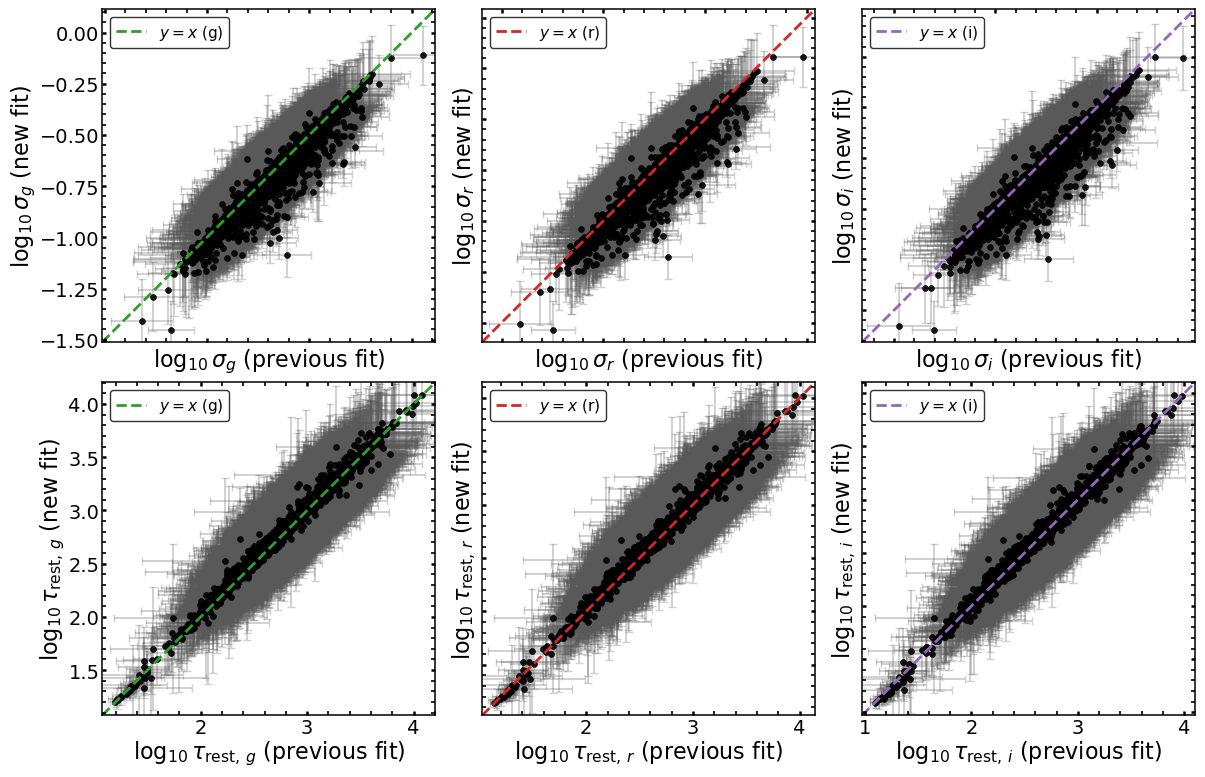

In [ ]:
# New fit compare
sigma_keys = {
    'x': 'log_sigma_band_{band}_sep8',
    'y': 'log_sigma_band_{band}_lmc4',
    'xerr': 'log_sigma_band_{band}_err_sep8',
    'yerr': 'log_sigma_band_{band}_err_lmc4',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (previous fit)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (new fit)',
}

tau_keys = {
    'x': 'log_tau_band_{band}_RF_sep8',
    'y': 'log_tau_band_{band}_RF_lmc4',
    'xerr': 'log_tau_band_{band}_RF_err_sep8',
    'yerr': 'log_tau_band_{band}_RF_err_lmc4',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (previous fit)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (new fit)',
}


agn_df_sep8 = load_agn_data("results/data/aug29_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4_fittedm2500_diffalpha.h5", populate_sdss=False, apply_cut=False)
agn_df_sep8['object_id'] = agn_df_sep8['object_id'].astype(str)

agn_df_lmc4 = load_agn_data("results/data/aug31_chisq_alphalamcsv_nobwb_poly1_N20w4000s1000t8c4_fittedm2500.h5", populate_sdss=False, apply_cut=False)
agn_df_lmc4['object_id'] = agn_df_lmc4['object_id'].astype(str)

merged_df = pd.merge(agn_df_sep8, agn_df_lmc4, on='object_id', how='inner', suffixes=('_sep8', '_lmc4'))
plot_stone_vs_this_work(merged_df, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/test/sigma_tau_sep8new.pdf")
